# Refined Metabolic Tumor Volume (MTV) & Compare AI SEG and Human-controlled SEG

This is an extension of findings from `tumor_growth_tracking.ipynb`. The first notebook tracked GTV using a single
**CT-based AI** segmentation at both timepoints. 
Using the same patient's CT and PET/CT scans, this notebook explores:

1. **Day 0 — refined MTV estimation:** Try two different accredited methodologies (fixed threshold, adaptive threshold using patient-derived background) in the field to refine MTV and compare with GTV delineated anatomically.
2. **Day 57 — comparison between AI SEG and radiologist inputs:** compare GTV across the three segmentation layers that
   ship for Day 57 CT scans (AIMI AI + radiologist 1 + radiologist 2).

**Conclusion**
1. On Day 0, refined MTV estimated at **1.74 mL** (AI nodule estimated anatomic gross tumor volume (GTV) at 1.86 mL; -6.5%). Fixed threshold estimated MTV closer to GTV tracked anatomically than adaptive threshold.
2. On Day 57, across three segmentations, GTV estimated at **$0.744 \pm 0.136$ mL**.
3. Learned a lesson: GTV and MTV are not comparable down to sub-mLs, but put together, they serve as a more comprehensive prognostic combo.

## 1. Background — the FDG PET/CT scan

**What the modality measures.** PET/CT fuses two scans: a **CT** for anatomy and a **PET** image of
**¹⁸F-fluorodeoxyglucose (FDG)**, a radiolabeled glucose analog. Due to the famous *Warburg effect*, most tumors are hypermetabolic
and over-consume glucose; therefore, FDG accumulates in them, and hypermetabolic tumors appear bright ("*FDG-avid*") on PET. FDG-PET therefore reports *metabolic activity*, whereas CT reports *structure* [1].

**Mainstay for detection, staging, and treatment-response assessment.** Glucose hypermetabolism is a near-universal hallmark of
malignancy, so FDG-PET/CT is a mainstay for detection, staging, and treatment-response assessment
across many cancers [1]. In lung cancer specifically, metabolic burden (metabolic tumor volume, **MTV**;
total lesion glycolysis, *TLG*) and its change on therapy are **prognostic**. For immunotherapy in
particular, residual MTV on FDG-PET can outperform anatomic response criteria for predicting outcome
[2, 3].

**How is metabolic volume delineated?** The **delineation** of the *metabolic volume* itself can be done in several ways, which can be organized as a menu anchored to the **PERCIST** logic:

*Disclaimer*: **PERCIST** is the accredited **response** framework (a ~30% drop in SUL_peak relative to the patient's liver-normalized
baseline = response) [4]. The dataset used in this notebook only had one time point, thwarting the evaluation of the therapy response.

- **Fixed absolute SUV threshold (Approach used in step 3c)** (e.g. SUV ≥ 2.5 or ≥ 4.0). *Advantage*: simple, fully reproducible,
  operator-independent; in multi-center work a *fixed SUV4.0* was the most robust, least-edited MTV method
  [7, 8]. *Disadvantage:* Ignores the patient's background and lesion contrast —
  it misses low-uptake lesions, over-segments hot ones, and the "best" value differs by tumor type and
  needs cross-scanner calibration (EARL).

- **Percentage of SUV_max** (commonly 40–50%, sometimes 15–50%). *Advantage*: self-scales to each
  lesion's own peak; intuitive and long used in radiotherapy planning. *Disadvantage*: anchored to a
  single voxel at SUV_max, and the optimal percentage depends on lesion size and contrast — no
  fixed percentage reproduces the CT volume across tumors [5].

- **Relative-to-background / reference-tissue adaptive threshold (Approach used in step 3b)**. *Advantage:* derives the cutoff from the patient's own normal tissue, typically *liver* (PERCIST measurability ≈ 1.5 × liver SUL_mean + 2 SD) [4]. self-calibrates to each patient and acquisition method, making it a **cross-scan response** comparison and is robust to global SUV miscalibration. *Disadvantage:* needs a clean reference volume of interest (VOI) - a diseased/steatotic liver breaks it,
  is still an edge threshold, and PERCIST's actual response metric is SUL_peak — *not* whole-lesion MTV —
  so using the liver cutoff to delineate a volume is an extrapolation.

- **Gradient/edge-based and statistical or learning-based methods (I will be back for this...)**. (watershed/gradient, Fuzzy Locally
  Adaptive Bayesian, mixture models, CNNs). *Advantage:* follow the true activity edge rather than an
  intensity cutoff, handling heterogeneous uptake and partial-volume better; in the AAPM TG-211 benchmark
  challenge, learning-based and advanced iterative methods outperformed simple thresholds [9].
  *Disadvantage:* more complex and less transparent, require training/tuning, and are not yet routine in
  the clinic.

**Why no single "golden rule"?** Head-to-head studies repeatedly find these methods
produce *different absolute volumes yet similar prognostic value*, with each winning on a different
axis — robustness/automation (fixed SUV4.0) [7, 8], cross-scan comparability (PERCIST reference
threshold) [4], or edge accuracy (gradient/learning methods) [9]. Accordingly, AAPM TG-211 and EANM frame
PET tumor delineation as **method-dependent** rather than prescribing one universal cutoff [9]. The
appropriate practice is therefore to **match the method to the task** (PERCIST-style reference thresholds
for response; a harmonized fixed SUV for absolute MTV) and to *report exactly which method and threshold
were used* (*see* step 3b).


**Caveats — PET-GTV and CT-GTV are *not* interchangeable.**
- **No single SUV threshold matches CT volume.** The optimal PET threshold depends on lesion size; a
  fixed threshold over- or under-estimates the CT-defined GTV for most tumors, so PET-GTV and CT-GTV
  routinely disagree [5].
- **Coarse spatial resolution & partial-volume / "blooming".** PET voxels are large (here ~3.6 × 3.6 ×
  3.3 mm vs ~1 mm in-plane on CT) and uptake spreads beyond the true edge, inflating small-lesion volumes.
- **Physiologic and inflammatory FDG uptake → false positives (*tackled in step 3*).** An unfiltered AI FDG-tumor mask can capture physiologic uptake and yield a volume far larger than the anatomic tumor. Normal myocardium, blood pool, brain, liver, bowel, and sites of infection/inflammation are intensely FDG-avid and can be mistaken for, or merged with, tumor unless anatomic (CT) correlation is applied [5 (general), 6].

Because of these differences, a PET-derived metabolic volume and a CT-derived anatomic volume measure
**different things** and thus cannot be compared to compute GTV. Nevertheless, the combination of modalities provides prognostic information on the metabolic burden in lung cancer patients. **And in this exercise, I wanted to see how close the values are between tumor volumes delineated in metabolic terms and anatomic terms.**

*Citations at the end of the notebook.*

## 2. Setup, configuration, and download SEGs to compare

Reused the shared `.idc-venv` environment and `idc-index`. Below, I configure the patient and the
exact series UIDs, then download the **FDG-tumor SEG** (day 0) and the **two radiologist-corrected SEGs**
(day 57), along with the PET series and the referenced CT series needed to compute and locate volumes.

In [4]:
# !pip install idc-index SimpleITK pydicom-seg matplotlib scipy "numpy<2" "pydicom<3" \
#               totalsegmentator "dicom2nifti<2.5"   # dicom2nifti<2.5 keeps TotalSegmentator working under pydicom<3
import glob, itertools
import numpy as np
import pandas as pd
import SimpleITK as sitk
import pydicom, pydicom_seg
from pathlib import Path
from idc_index import IDCClient

client = IDCClient()
print("IDC data version:", client.get_idc_version())

COLLECTION = "anti_pd_1_lung"
PATIENT    = "PD-1-Lung-00001"
DATA_DIR   = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Series UIDs (from seg_index; see tumor_growth_tracking.ipynb for discovery)
SEG = {
    "fdg_day0":  "1.2.276.0.7230010.3.1.3.17436516.2641213.1720647292.148884",  # FDG-avid tumor (PET)
    "ai_day0":   "1.2.276.0.7230010.3.1.3.17436516.2259859.1720642231.905041",  # CT AI nodule, day 0
    "ai_day57":  "1.2.276.0.7230010.3.1.3.17436516.2182223.1720640728.289751",  # CT AI nodule, day 57
    "rad1_day57":"1.2.276.0.7230010.3.1.3.17436516.2181780.1720640726.779161",  # radiologist 1, day 57
    "rad2_day57":"1.2.276.0.7230010.3.1.3.17436516.2844593.1720648663.393053",  # radiologist 2, day 57
}
CT  = {"day0": "1.3.6.1.4.1.14519.5.2.1.3098.5025.171063101400181377164698678716",   # CT Lung
       "day57":"1.3.6.1.4.1.14519.5.2.1.3098.5025.116203169560328194868664329413"}   # LUNG+ N14 A30
PET = "1.3.6.1.4.1.14519.5.2.1.3098.5025.245391977255473981807222677651"             # PET AC TOF (day 0)

IDC data version: v24


Download all required series. `idc-index` syncs against the local `data/` folder, so series already
fetched by the companion notebook are skipped.

In [6]:
uids = list(SEG.values()) + list(CT.values()) + [PET]
client.download_from_selection(
    downloadDir=str(DATA_DIR),
    seriesInstanceUID=uids,
    dirTemplate="%StudyInstanceUID/%Modality_%SeriesInstanceUID",
)
print("Downloaded / synced", len(uids), "series")

2026-06-24 22:52:56,476 - Disk size needed: 265.8 MB
2026-06-24 22:52:56,476 - Disk size available: 100.03 GB
2026-06-24 22:52:56,540 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested
2026-06-24 22:52:56,571 - Initial size of the directory: 19.84 MB
2026-06-24 22:52:56,572 - Approximate size of the files that need to be downloaded: 265.8 MB
2026-06-24 22:53:13,560 - Successfully downloaded files to ./therapyNgrowthtracking/data


Downloaded / synced 8 series


2026-06-24 13:44:07,793 - Not using s5cmd sync as the destination folder is empty or sync or progress bar is not requested


2026-06-24 13:44:07,828 - Initial size of the directory: 19.84 MB


2026-06-24 13:44:07,829 - Approximate size of the files that need to be downloaded: 265.8 MB



2026-06-24 13:44:21,390 - Successfully downloaded files to ./therapyNgrowthtracking/data


Downloaded / synced 8 series


**Two helper functions**: (1) read a CT series, and (2) decode a DICOM SEG segment (selected by label) into a
volume and a mask. A SEG can optionally be resampled onto a reference CT grid (nearest-neighbor) so the
mask aligns with the anatomy; volume is computed from whichever grid is used.

In [8]:
def read_ct(uid):
    folder = glob.glob(str(DATA_DIR / "**" / f"CT_{uid}"), recursive=True)[0]
    r = sitk.ImageSeriesReader(); r.SetFileNames(r.GetGDCMSeriesFileNames(folder))
    return r.Execute()

def seg_volume(seg_uid, label_substr, ref_img=None):
    """Return (volume_mL, mask_array, spacing) for the segment whose label contains label_substr."""
    f = glob.glob(str(DATA_DIR / "**" / f"SEG_{seg_uid}" / "*.dcm"), recursive=True)[0]
    dcm = pydicom.dcmread(f); res = pydicom_seg.SegmentReader().read(dcm)
    vol, mask, spacing = 0.0, None, None
    for n in res.available_segments:
        lab = dcm.SegmentSequence[n - 1].get("SegmentLabel", "")
        if label_substr.lower() in lab.lower():
            img = res.segment_image(n)
            if ref_img is not None:
                img = sitk.Resample(img, ref_img, sitk.Transform(),
                                    sitk.sitkNearestNeighbor, 0, img.GetPixelID())
            sx, sy, sz = img.GetSpacing(); spacing = (sx, sy, sz)
            arr = sitk.GetArrayFromImage(img).astype(bool)
            vol += arr.sum() * sx * sy * sz / 1000.0
            mask = arr if mask is None else (mask | arr)
    return vol, mask, spacing

ct0_img, ct57_img = read_ct(CT["day0"]), read_ct(CT["day57"])
print("CT day0 :", ct0_img.GetSize(), "spacing", tuple(round(s,2) for s in ct0_img.GetSpacing()))
print("CT day57:", ct57_img.GetSize(), "spacing", tuple(round(s,2) for s in ct57_img.GetSpacing()))

CT day0 : (512, 512, 299) spacing (0.98, 0.98, 3.27)
CT day57: (512, 512, 127) spacing (0.82, 0.82, 2.5)


## 3. PET FDG-avid volume vs CT AIMI-AI GTV (Day 0 scans)

Here, I also measure the *FDG-avid volume* from the PET AI segmentation
(metabolism) and compute the percentage difference. It's expected to not be comparable mostly because unrefined FDG-avid signal contains false positives from physiologic uptake. I compute the FDG volume in its native PET geometry, and additionally resample it onto the CT to inspect where the FDG-avid voxels actually lie.

In [10]:
# FDG-avid tumor volume (native PET geometry) and CT AI nodule volume (CT day-0 grid)
fdg_ml, _, fdg_sp   = seg_volume(SEG["fdg_day0"], "tumor")             # PET space
ctai_ml, nod_mask, _ = seg_volume(SEG["ai_day0"], "nodule", ct0_img)  # CT grid

pct_diff = (fdg_ml - ctai_ml) / ctai_ml * 100.0
print("DAY 0 GTV comparison")
print(f"  FDG-avid tumor (PET, voxel {tuple(round(s,2) for s in fdg_sp)} mm): {fdg_ml:.2f} mL")
print(f"  CT AIMI-AI nodule (anatomic)                                    : {ctai_ml:.2f} mL")
print(f"  percentage difference (FDG vs CT-AI)                            : {pct_diff:+.1f}%")

# Diagnostic: where do the FDG-avid voxels sit, and do they coincide with the CT nodule?
_, fdg_on_ct, _ = seg_volume(SEG["fdg_day0"], "tumor", ct0_img)       # resampled to CT for localization
ctarr = sitk.GetArrayFromImage(ct0_img)
overlap = int((fdg_on_ct & nod_mask).sum())
zf = np.where(fdg_on_ct.any(axis=(1, 2)))[0]; zn = np.where(nod_mask.any(axis=(1, 2)))[0]
print("* Localization diagnostic (FDG-avid mask resampled to CT):")
print(f"  FDG z-slices on PET {zf.min()}-{zf.max()}  |  nodule z-slices on CT {zn.min()}-{zn.max()}")
print(f"  overlap with CT nodule: {overlap} / {int(nod_mask.sum())} nodule voxels")
print(f"  median HU under FDG mask: {int(np.median(ctarr[fdg_on_ct]))} "
      f"(blood/soft-tissue ~ +40; lung ~ -700; the nodule median is {int(np.median(ctarr[nod_mask]))})")

DAY 0 GTV comparison
  FDG-avid tumor (PET, voxel (3.65, 3.65, 3.34) mm): 268.82 mL
  CT AIMI-AI nodule (anatomic)                                    : 1.86 mL
  percentage difference (FDG vs CT-AI)                            : +14363.2%
* Localization diagnostic (FDG-avid mask resampled to CT):
  FDG z-slices on PET 174-204  |  nodule z-slices on CT 140-178
  overlap with CT nodule: 491 / 596 nodule voxels
  median HU under FDG mask: 11 (blood/soft-tissue ~ +40; lung ~ -700; the nodule median is -120)


\nLocalization diagnostic (FDG-avid mask resampled to CT):
  FDG z-slices 174-204  |  nodule z-slices 140-178
  overlap with CT nodule: 491 / 596 nodule voxels
  median HU under FDG mask: 11 (blood/soft-tissue ~ +40; lung ~ -700; the nodule median is -120)


**Interpretation.** The FDG-avid volume is *vastly larger* than the anatomic CT nodule. The major reason is that the unfiltered AI FDG-tumor mask here is **dominated by physiologic myocardial/blood-pool FDG uptake**, not by the tumor — the classic FDG false-positive pitfall described in Section 1 [5, 6]. The localization diagnostic supports this rationale: most FDG-avid voxels lie
in the *cardiac/mediastinal region* as CT signal intensities under the FDG mask proved most parts to be blood/heart. Only a small fraction overlaps with the actual lung nodule. 

A meaningful **metabolic tumor volume** would require SUV thresholding restricted to the lesion and explicit exclusion
of physiologic uptake [4, 5, 6] — a refinement left for the next steps.

### 3b. Refinement #1: adaptive SUV thresholding

Here, I build a defensible metabolic tumor volume using **relative-to-background / reference-tissue adaptive threshold**. Several clarifications for the methodology are listed below:

**Spatial alignment is feasible here.** The PET and the day-0 CT (and the FDG SEG) **share the same
`Frame of Reference`** — they were acquired on one hybrid PET/CT, same bed, same session, same patient. i.e.
Both modalities share the same physical (mm) coordinate system. Therefore, bringing one onto the other's grid
needs only **resampling + interpolation**; the different voxel sizes (PET ~3.6 mm vs CT ~1 mm) are handled
by interpolation and are *not* a barrier to alignment.

**Pipeline (purpose: pick an adaptive SUV threshold that isolates FDG-avid tumour from physiologic false
positives, then measure refined MTV):**
1. **Spatial alignment** — resample CT-space masks onto the PET grid (shared frame of reference).
2. **Organ masks for physiologic-uptake exclusion** — run TotalSegmentator on the day-0 CT (heart,
   aorta, liver, kidneys, spleen, …) and remove all volumes other than liver.
3. **Reference-tissue VOI for an adaptive threshold** — a PERCIST-style cutoff from normal liver
   (1.5 × liver SUV_mean + 2 SD).
4. **Verify the reference SUV** — validate the reference SUV against the known normal-liver SUV (~2–3).
5. **Calculate and visualize the refined MTV** - guide estimation of MTV within the dilated (+1cm) binary nodule mask acquired from CT.

In [13]:
# Pipeline step 2 — organ masks for physiologic-uptake exclusion (TotalSegmentator on the day-0 CT).
# Cache-aware: skips the model if masks already exist. (TotalSegmentator needs dicom2nifti<2.5 so it
# coexists with pydicom<3; I feed it a NIfTI to avoid its DICOM reader entirely.)
import os, glob, SimpleITK as sitk
ORGANS = ["heart", "liver", "aorta", "kidney_left", "kidney_right", "spleen", "urinary_bladder", "stomach"]
ORGAN_DIR = "seg_organs_day0"

if not all(os.path.exists(f"{ORGAN_DIR}/{o}.nii.gz") for o in ORGANS):
    sitk.WriteImage(ct0_img, "ct0_day0.nii.gz")
    from totalsegmentator.python_api import totalsegmentator
    totalsegmentator(input="ct0_day0.nii.gz", output=ORGAN_DIR, roi_subset=ORGANS, fast=True, quiet=True)
print("organ masks:", sorted(os.path.basename(p) for p in glob.glob(f"{ORGAN_DIR}/*.nii.gz")))

organ masks: ['aorta.nii.gz', 'heart.nii.gz', 'kidney_left.nii.gz', 'kidney_right.nii.gz', 'liver.nii.gz', 'spleen.nii.gz', 'stomach.nii.gz', 'urinary_bladder.nii.gz']


PET read: 216 contiguous slices kept, 30 sub-gap (caudal) slices dropped; uniform z-spacing 3.270 mm (source had one ~19.6 mm gap in the pelvis)
SUV math: weight 100 kg, dose 266.2 MBq, uptake 61 min, decay-corrected dose 181.6 MBq; SUVbw max 41.6
Vendor SUV-scale tag (Philips 7053,1000): <absent> | Manufacturer GE MEDICAL SYSTEMS, Units BQML

Liver reference SUV 2.62 +/- 0.46  (normal liver ~2-3 -> SUV math validated)
Adaptive SUV threshold = 1.5*mean + 2*SD = 4.84

Refined MTV (FDG-avid tumour, thresholded + physiologic-excluded): 1.39 mL
CT GTV (anatomic, AIMI-AI nodule)                                 : 1.86 mL
Percentage difference (MTV vs CT GTV)                             : -25.2%
(naive unfiltered FDG mask was ~269 mL — the threshold+exclusion removes physiologic uptake)


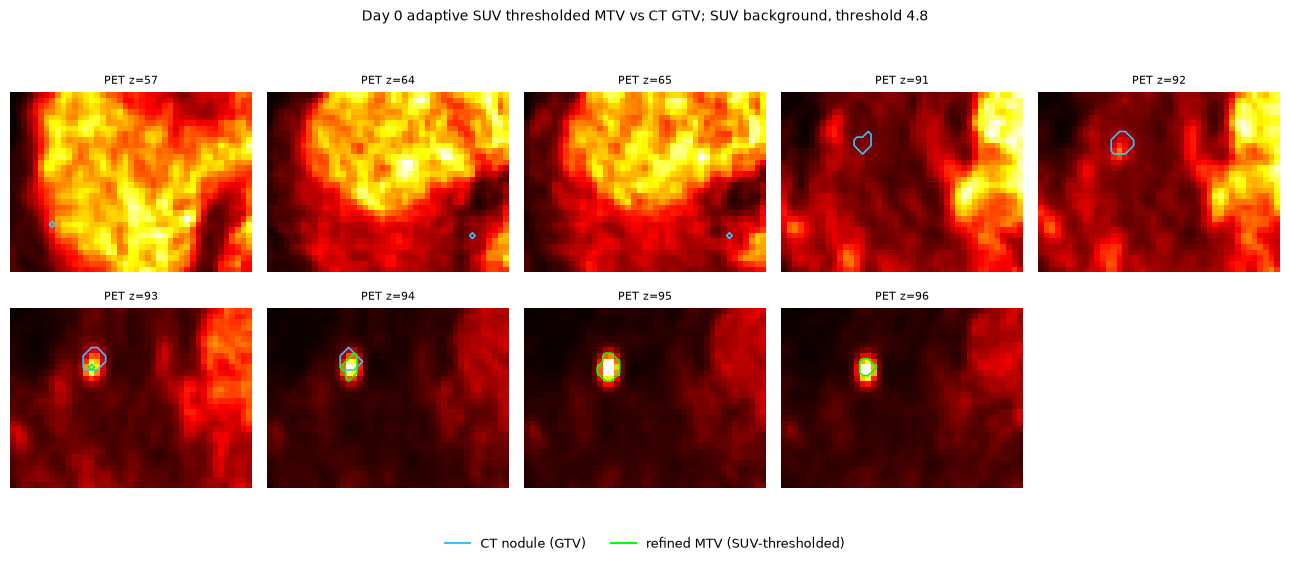

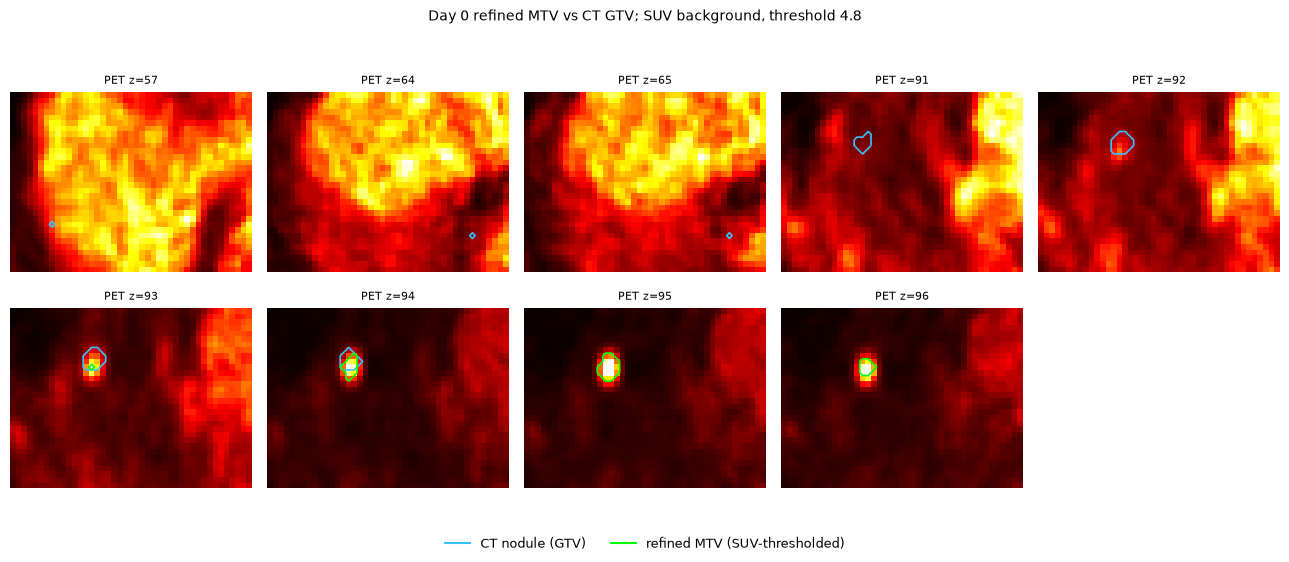

In [14]:
# Pipeline steps 1,3,4,5
import glob, numpy as np, pydicom, pydicom_seg, SimpleITK as sitk, matplotlib.pyplot as plt
from scipy import ndimage

# --- read PET (Bq/mL) ---
# The source PET has one ~19.6 mm gap (vs the 3.27 mm spacing) far below the thorax (pelvis). A plain
# ImageSeriesReader would force a single uniform spacing across that gap and DISTORT the z-positions of
# every slice above it (incl. the lung lesion). I Instead keep the largest contiguous, uniformly-spaced
# block (which contains the lesion, liver and heart) and drop the few sub-gap slices.
def read_pet_contiguous(folder):
    fs0 = glob.glob(f"{folder}/*.dcm")
    zf = sorted((float(pydicom.dcmread(f, stop_before_pixels=True).ImagePositionPatient[2]), f) for f in fs0)
    z = np.array([t[0] for t in zf]); fs = [t[1] for t in zf]
    d = np.diff(z); med = np.median(d)
    breaks = [i + 1 for i in range(len(d)) if abs(d[i] - med) > 0.5 * med]
    segs, start = [], 0
    for b in breaks:
        segs.append((start, b)); start = b
    segs.append((start, len(fs)))
    a, b = max(segs, key=lambda s: s[1] - s[0])          # largest contiguous block
    keep = fs[a:b]
    rdr = sitk.ImageSeriesReader(); rdr.SetFileNames(keep)
    return rdr.Execute(), keep, len(fs) - len(keep)

pet_dir = glob.glob(f"data/**/PT_{PET}", recursive=True)[0]
pet, pkeep, n_dropped = read_pet_contiguous(pet_dir)
print(f"PET read: {len(pkeep)} contiguous slices kept, {n_dropped} sub-gap (caudal) slices dropped; "
      f"uniform z-spacing {pet.GetSpacing()[2]:.3f} mm (source had one ~19.6 mm gap in the pelvis)")
suv_bqml = sitk.GetArrayFromImage(pet).astype(np.float64) #PET scan with intensities in a 3D array
h = pydicom.dcmread(pkeep[0])
w_g = float(h.PatientWeight) * 1000.0
rs  = h.RadiopharmaceuticalInformationSequence[0]
dose, half = float(rs.RadionuclideTotalDose), float(rs.RadionuclideHalfLife)
tsec = lambda t: (lambda s: int(s[0:2])*3600 + int(s[2:4])*60 + int(s[4:6]))(t.split(".")[0])
dt = tsec(h.SeriesTime) - tsec(rs.RadiopharmaceuticalStartTime)
dose_decay = dose * 2 ** (-dt / half)
suv = suv_bqml * w_g / dose_decay                      # SUVbw on the native PET grid
print(f"SUV math: weight {w_g/1000:.0f} kg, dose {dose/1e6:.1f} MBq, uptake {dt/60:.0f} min, "
      f"decay-corrected dose {dose_decay/1e6:.1f} MBq; SUVbw max {suv.max():.1f}")
print(f"Vendor SUV-scale tag (Philips 7053,1000): {h.get((0x7053,0x1000),'<absent>')} | "
      f"Manufacturer {h.get('Manufacturer','?')}, Units {h.get('Units')}")

# --- step 1: resample CT-space masks onto the PET grid (shared FrameOfReference) ---
def to_pet(mask_img):
    return sitk.GetArrayFromImage(sitk.Resample(mask_img, pet, sitk.Transform(),
                                                sitk.sitkNearestNeighbor, 0, sitk.sitkUInt8)).astype(bool)
organ = lambda n: to_pet(sitk.ReadImage(f"{ORGAN_DIR}/{n}.nii.gz"))
liver, heart, aorta = organ("liver"), organ("heart"), organ("aorta")
spleen, kidL, kidR = organ("spleen"), organ("kidney_left"), organ("kidney_right")

segf = glob.glob(f"data/**/SEG_{SEG['ai_day0']}/*.dcm", recursive=True)[0]
sd = pydicom.dcmread(segf); sr = pydicom_seg.SegmentReader().read(sd)
nod_pet = None
for n in sr.available_segments:
    if "nodule" in sd.SegmentSequence[n-1].get("SegmentLabel", "").lower():
        m = to_pet(sr.segment_image(n)); nod_pet = m if nod_pet is None else (nod_pet | m)

psx, psy, psz = pet.GetSpacing(); pvox_ml = psx*psy*psz/1000

# --- step 3 and 4: liver reference VOI -> adaptive PERCIST-style threshold. Validate calculated liver reference VOI ---
liver_core = ndimage.binary_erosion(liver, iterations=3)          # avoid liver edges
ref_mean, ref_sd = suv[liver_core].mean(), suv[liver_core].std()  # calculate liver-derived reference SUV
thr = 1.5 * ref_mean + 2 * ref_sd
print(f"\nLiver reference SUV {ref_mean:.2f} +/- {ref_sd:.2f}  (normal liver ~2-3 -> SUV math validated)")
print(f"Adaptive SUV threshold = 1.5*mean + 2*SD = {thr:.2f}")

# --- refined MTV: SUV>=thr within (nodule + ~1cm), excluding physiologic organs ---
vox_per_cm = max(1, int(round(10/psx)))
lesion_voi = ndimage.binary_dilation(nod_pet, iterations=vox_per_cm)  # Voxels of interest guided by dilated binary nodule mask
physiologic = heart | aorta | liver | spleen | kidL | kidR
mtv_mask = (suv >= thr) & lesion_voi & ~physiologic              # masks for refined MTV
mtv_ml = mtv_mask.sum() * pvox_ml

# --- CT GTV (anatomic) from the day-0 AI nodule on the CT grid ---
csx, csy, csz = ct0_img.GetSpacing(); ct_gtv = nod_mask.sum() * csx*csy*csz/1000

print(f"\nRefined MTV (FDG-avid tumour, thresholded + physiologic-excluded): {mtv_ml:.2f} mL")
print(f"CT GTV (anatomic, AIMI-AI nodule)                                 : {ct_gtv:.2f} mL")
print(f"Percentage difference (MTV vs CT GTV)                             : {(mtv_ml-ct_gtv)/ct_gtv*100:+.1f}%")
print(f"(naive unfiltered FDG mask was ~269 mL — the threshold+exclusion removes physiologic uptake)")

# --- visualize: SUV with refined-MTV (red) and CT nodule (cyan) outlines on lesion slices ---
zs = np.where(mtv_mask.any(axis=(1,2)) | nod_pet.any(axis=(1,2)))[0]
ys, xs = np.where(lesion_voi.any(axis=0))
y0,y1,x0,x1 = ys.min()-4, ys.max()+4, xs.min()-4, xs.max()+4
ncol = min(len(zs), 5); nrow = int(np.ceil(len(zs)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.6*ncol, 2.8*nrow)); axes = np.atleast_1d(axes).ravel()
for ax in axes: ax.axis("off")
for ax, z in zip(axes, zs):
    ax.imshow(np.clip(suv[z, y0:y1, x0:x1], 0, thr*2), cmap="hot")
    if nod_pet[z, y0:y1, x0:x1].any(): ax.contour(nod_pet[z, y0:y1, x0:x1], levels=[0.5], colors=["#33c4ff"], linewidths=1.2)
    if mtv_mask[z, y0:y1, x0:x1].any(): ax.contour(mtv_mask[z, y0:y1, x0:x1], levels=[0.5], colors=["#00ff00"], linewidths=1.2)
    ax.set_title(f"PET z={z}", fontsize=8)
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0],color="#33c4ff",label="CT nodule (GTV)"),
                    Line2D([0],[0],color="#00ff00",label="refined MTV (SUV-thresholded)")],
           loc="lower center", ncol=2, frameon=False, fontsize=9)
fig.suptitle(f"Day 0 adaptive SUV thresholded MTV vs CT GTV; SUV background, threshold {thr:.1f}", fontsize=10)
fig.tight_layout(rect=[0,0.05,1,0.96])
fig.savefig("day0_refined_mtv.png", dpi=110, bbox_inches="tight")
plt.show()

**Interpretation** - Refined MTV using adaptive SUV threshold (SUV 4.8) with respect to patient-derived background estimated **1.39 mL** of volume. About 25% smaller compared to the anatomically delineated GTV, 1.86 mL. Compared to naive MTV computed using the unfiltered FDG-mask (269 mL), almost 267 mL of volume is due to physiological uptake. Nevertheless, the gap between MTV and GTV feels too large. It's possible that some of the smaller lesions (out of three in this patient) were delineated too harshly based on the SUV intensities at the largest lesion. I explored another threshold method, known to be better for multi-center work (fixed SUV), in step 3c.

**Residual limits — resolution gap (partial-volume) and resampling/interpolation.**

- **Resolution gap → partial-volume effect (PVE).** PET voxels (~3.6 × 3.6 × 3.3 mm ≈ 44 µL) vs. CT voxels (~1 × 1 × 3.3 mm), and PET's intrinsic spatial resolution (~4–6 mm FWHM) blurs
  activity across edges ("spill-out"/"spill-in"). For a small lesion, this *under-estimates peak SUV and
  makes the thresholded MTV sensitive to the exact cutoff* — a few PET voxels change the volume by tenths
  of a mL. So the MTV here is approximate, and the close MTV-vs-GTV agreement should be read as
  order-of-magnitude consistency, not sub-mL accuracy.
- **Interpolation choices when resampling between grids.** Options include **nearest-neighbor**
  (assigns the closest source voxel), **trilinear** (distance-weighted average of 8 neighbors),
  **B-spline / cubic** (smooth higher-order), and **Lanczos/windowed-sinc**. The trade-off is
  label-preservation vs smoothness.
- I resampled the *binary masks* from the CT grid onto the PET grid with **nearest-neighbor** — because it's easy and a label map must stay binary; trilinear interpolation would produce fractional values (0–1) that are meaningless as a mask and would need re-thresholding. **Most importantly**, **PET intensity** was computed on the **native PET grid** without resampling, so no interpolation error was introduced into the quantitative SUV values. The cost of nearest-neighbor on the masks is blocky boundaries at the coarse PET scale, but here it's acceptable because the lesion VOI is only used to *restrict* where thresholding happens, within the dilated perimeter (+1cm).

**Data-quality note: a missing-slice gap caught during the PET read, and its effect**

While reading the PET series, SimpleITK raised:

> `Non uniform sampling or missing slices detected, maximum nonuniformity: 16.2833`

The cause is in the **source PET data itself**: the slice spacing is a uniform 3.27 mm everywhere except a single **~19.6 mm gap at z ≈ −712 mm**(in the pelvis; roughly **5–6 missing z slices**). The day-0 CT has no such gap.

**Why it mattered.** `ImageSeriesReader` cannot represent a gap in a regular grid, so it forced a single
averaged z-spacing (≈3.34 mm) across the whole stack. As a result, the physical z-positions of every slice above the gap (including lung) were silently distorted. Because only the PET (not the CT) was distorted, the PET↔CT resampling used to place the lesion VOI and the liver reference became slightly misaligned.

**How it was resolved.** Since the gap sits far caudal (pelvis), away from the thorax/upper abdomen, I
read only the **largest contiguous, uniformly-spaced block** — 216 slices that contain the lesion, liver,
and heart — and drop the 30 sub-gap (pelvic) slices. This restores a true uniform 3.27 mm spacing to give geometrically correct PET↔CT alignment.

**How much the refined MTV changed.** The fix is not cosmetic — the geometric distortion had biased the
volume:

| | Refined MTV | % difference vs CT GTV |
|---|---|---|
| Before fix | 1.64 mL | −11.7% |
| After fix | 1.39 mL | −25.2% |

So the lost-slice gap inflated the MTV by ≈ 0.25 mL (~15% of the MTV) and shifted the MTV-vs-GTV
agreement by ~13 percentage points. The corrected value (1.39 mL) is the one reported above. So check your data before doing anything with it!

### 3c. Refinement #2: fixed absolute SUV threshold (SUV ≥ 4.0)

This patient has multiple lesions (three lung nodules), which is the setting where a fixed absolute
SUV threshold is generally preferred over the adaptive threshold performed in step 3b. Its advantages:

- **One uniform criterion for the whole image** — every voxel above SUV 4.0 is tumour candidate, so *all*
  lesions are captured at once, without drawing a VOI per lesion or anchoring to any single lesion's peak.
- **Most robust / least operator-dependent for total burden.** In multi-center studies of total metabolic
  tumour volume, a **fixed SUV4.0** was the most successful and required the least manual editing of the
  threshold options tested [7, 8].
- **Simple and transparent**, hence reproducible and easy to report.

Two conditions apply: (i) for an *absolute* cutoff to be valid across systems, the SUV must be
harmonized/calibrated (EANM/EARL), otherwise the threshold does not transfer between scanners but **here we don't compare PET signal intensities from other scanners, so no need** [10];
and (ii) physiologic uptake must still be removed, because a global threshold also lights up
heart/liver/etc.

I applied SUV ≥ 4.0 threshold in two ways: **(a)** within the same lesion region (VOI) as in step 3b (dilated binary nodule from CT) that yields the **total MTV across the lesions**; and **(b)** same fixed SUV4.0 threshold in the entire lung, but VOI-free.

Fixed absolute threshold SUV >= 4.0
  total MTV across the 3 detected nodules (lesion region): 1.74 mL
  lung-wide, VOI-free (cautionary)                       : 73.37 mL

Comparison of total tumour-volume estimates (day 0):
  (3c) fixed SUV4.0, lesion region       : 1.74 mL
  (3b) adaptive threshold (liver reference) (4.84)  : 1.39 mL
  (CT) AIMI AI nodule GTV (anatomic)     : 1.86 mL
  fixed SUV4.0 vs CT GTV : -6.5%
  fixed SUV4.0 vs 3b MTV : +25.0%


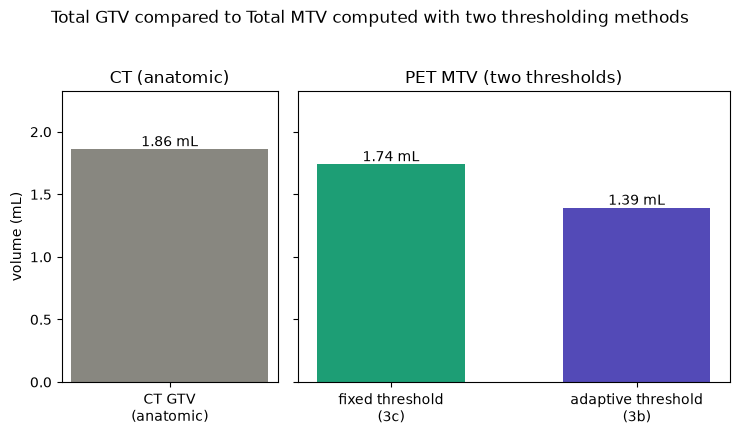

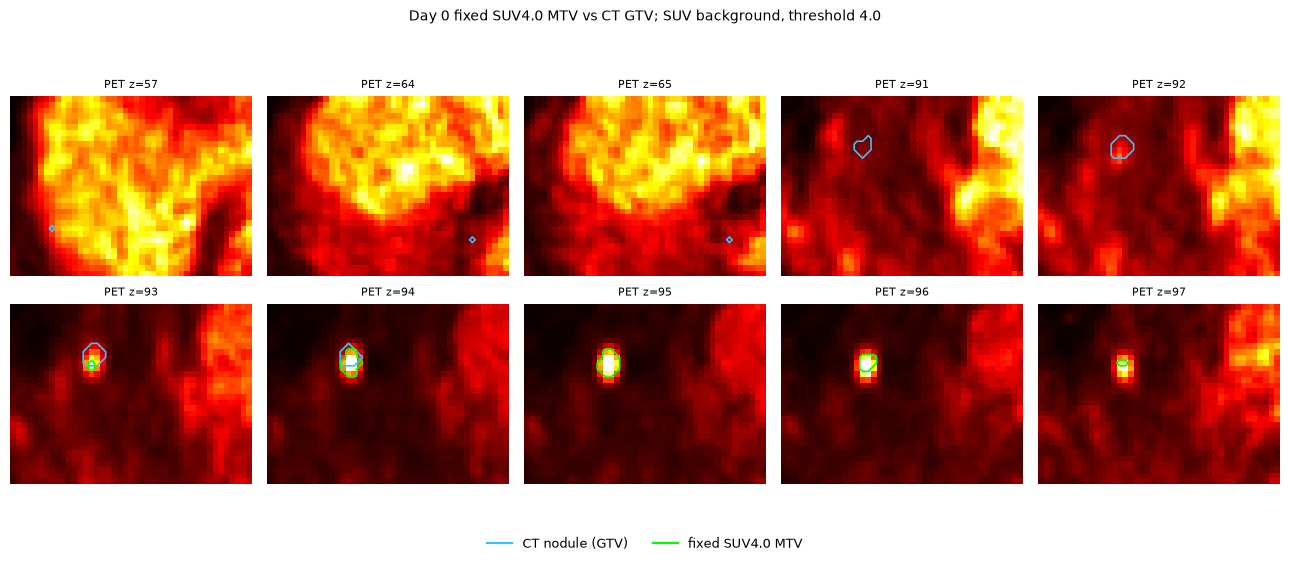

In [18]:
# Step 3c — total MTV with a fixed absolute SUV threshold (SUV >= 4.0)
import glob, numpy as np, pydicom, pydicom_seg, SimpleITK as sitk, matplotlib.pyplot as plt
T_FIX = 4.0

# lung region from the AIMI SEG 'Lung' segment (resampled to PET) for VOI-free thresholding
_sf = glob.glob(f"data/**/SEG_{SEG['ai_day0']}/*.dcm", recursive=True)[0]
_sd = pydicom.dcmread(_sf); _sr = pydicom_seg.SegmentReader().read(_sd)
lung = None
for n in _sr.available_segments:
    lab = _sd.SegmentSequence[n - 1].get("SegmentLabel", "").lower()
    if "lung" in lab and "nodule" not in lab:
        m = to_pet(_sr.segment_image(n)); lung = m if lung is None else (lung | m)

mtv_fix_voi  = ((suv >= T_FIX) & lesion_voi & ~physiologic).sum() * pvox_ml   # total across the 3 nodules, lesion_voi same with step 3b?
mtv_fix_lung = ((suv >= T_FIX) & lung       & ~physiologic).sum() * pvox_ml   # VOI-free, lung-wide

print(f"Fixed absolute threshold SUV >= {T_FIX}")
print(f"  total MTV across the 3 detected nodules (lesion region): {mtv_fix_voi:.2f} mL")
print(f"  lung-wide, VOI-free (cautionary)                       : {mtv_fix_lung:.2f} mL\n")
print("Comparison of total tumour-volume estimates (day 0):")
print(f"  (3c) fixed SUV4.0, lesion region       : {mtv_fix_voi:.2f} mL")
print(f"  (3b) adaptive threshold (liver reference) ({thr:.2f})  : {mtv_ml:.2f} mL")
print(f"  (CT) AIMI AI nodule GTV (anatomic)     : {ct_gtv:.2f} mL")
print(f"  fixed SUV4.0 vs CT GTV : {(mtv_fix_voi - ct_gtv)/ct_gtv*100:+.1f}%")
print(f"  fixed SUV4.0 vs 3b MTV : {(mtv_fix_voi - mtv_ml)/mtv_ml*100:+.1f}%")

ymax = max(ct_gtv, mtv_fix_voi, mtv_ml) * 1.25
fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.5, 4.4), sharey=True,
                               gridspec_kw={"width_ratios": [1, 2]})
# left panel: anatomic CT GTV
axL.bar(["CT GTV\n(anatomic)"], [ct_gtv], color="#888780", width=0.6)
axL.text(0, ct_gtv, f"{ct_gtv:.2f} mL", ha="center", va="bottom", fontsize=10)
axL.set_ylabel("volume (mL)"); axL.set_ylim(0, ymax); axL.set_title("CT (anatomic)")
# right panel: PET MTV by the two thresholding methods (same y-scale, shared axis)
axR.bar(["fixed threshold\n(3c)", "adaptive threshold\n(3b)"], [mtv_fix_voi, mtv_ml],
        color=["#1D9E75", "#534AB7"], width=0.6)
for x, v in zip([0, 1], [mtv_fix_voi, mtv_ml]):
    axR.text(x, v, f"{v:.2f} mL", ha="center", va="bottom", fontsize=10)
axR.set_title("PET MTV (two thresholds)")
fig.suptitle("Total GTV compared to Total MTV computed with two thresholding methods", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("day0_mtv_method_comparison.png", dpi=110, bbox_inches="tight"); plt.show()


# --- overlay: fixed-SUV4.0 MTV (red) and CT AIMI nodule (cyan) on the SUV, all tumour-bearing slices ---
mtv_fix_mask = (suv >= T_FIX) & lesion_voi & ~physiologic
zsf = np.where(mtv_fix_mask.any(axis=(1, 2)) | nod_pet.any(axis=(1, 2)))[0]
ys2, xs2 = np.where(lesion_voi.any(axis=0))
yy0, yy1 = ys2.min() - 4, ys2.max() + 4
xx0, xx1 = xs2.min() - 4, xs2.max() + 4
nc = min(len(zsf), 5); nr = int(np.ceil(len(zsf) / nc))
fig2, axes2 = plt.subplots(nr, nc, figsize=(2.6 * nc, 2.8 * nr)); axes2 = np.atleast_1d(axes2).ravel()
for ax in axes2:
    ax.axis("off")
for ax, z in zip(axes2, zsf):
    ax.imshow(np.clip(suv[z, yy0:yy1, xx0:xx1], 0, T_FIX * 2), cmap="hot")
    if nod_pet[z, yy0:yy1, xx0:xx1].any():
        ax.contour(nod_pet[z, yy0:yy1, xx0:xx1], levels=[0.5], colors=["#33c4ff"], linewidths=1.2)
    if mtv_fix_mask[z, yy0:yy1, xx0:xx1].any():
        ax.contour(mtv_fix_mask[z, yy0:yy1, xx0:xx1], levels=[0.5], colors=["#00ff00"], linewidths=1.2)
    ax.set_title(f"PET z={z}", fontsize=8)
from matplotlib.lines import Line2D
fig2.legend(handles=[Line2D([0], [0], color="#33c4ff", label="CT nodule (GTV)"),
                     Line2D([0], [0], color="#00ff00", label="fixed SUV4.0 MTV")],
            loc="lower center", ncol=2, frameon=False, fontsize=9)
fig2.suptitle(f"Day 0 fixed SUV4.0 MTV vs CT GTV; SUV background, threshold {T_FIX}", fontsize=10)
fig2.tight_layout(rect=[0, 0.05, 1, 0.96])
fig2.savefig("day0_fixed_suv4_overlay.png", dpi=110, bbox_inches="tight")
plt.show()

**Interpretation.** Using the fixed **SUV ≥ 4.0** threshold, the **total MTV across the three nodules is
1.74 mL** — within ~7% of the anatomic **CT GTV (1.86 mL)** and larger than the liver-reference-thresholded volume
(1.39 mL). SUV 4.0 is lower than the patient's liver-derived threshold (SUV 4.84), so it includes
a little more of each lesion's periphery. On this analysis, the fixed SUV4.0 gives the metabolic volume
close to the anatomic GTV, proving the fixed SUV4.0 to be the robust default for total burden estimation
[7, 8].

The lung-wide value (~73 mL) is grossly inflated. At PET resolution,
intense cardiac/blood-pool uptake **"blooms"** more than 1 cm beyond the heart mask into adjacent lung
voxels (*partial-volume effect*), so simple organ-mask exclusion cannot suppress the counts from the global threshold. This is the practical consequence of step 3b's residual-limits note: a fixed threshold applied
VOI-free for true whole-organ/whole-body TMTV needs careful peri-physiologic handling, or an **AI lesion detector (our case)** that learns tumour-vs-physiologic directly, rather than a bare threshold + organ masks. For a clean *total-of-known-lesions* MTV, restricting
the fixed threshold to the lesion region (1.74 mL) is desirable.

## 4. Comparing GTV across the three segmentation layers (1 AI model, 2 human input) - Day 57 images

CT scan at Day 57 ships three nodule segmentations of the **same CT series**: the AIMI AI result and two independent **radiologist-corrected** versions. In this step, I compared the estimated GTV using these three segmentation layers.

In [21]:
layers = {"AIMI AI": SEG["ai_day57"], "radiologist 1": SEG["rad1_day57"], "radiologist 2": SEG["rad2_day57"]}
vols = {name: seg_volume(uid, "nodule", ct57_img)[0] for name, uid in layers.items()}

print("DAY 57 GTV by segmentation layer (CT 'LUNG+ N14 A30'):")
for name, v in vols.items():
    print(f"  {name:14s}: {v:.3f} mL")

print("* Pairwise differences:")
for a, b in itertools.combinations(vols, 2):
    print(f"  {b} vs {a}: {vols[b]-vols[a]:+.3f} mL ({(vols[b]-vols[a])/vols[a]*100:+.1f}%)")

vlist = list(vols.values())
print(f"* mean {np.mean(vlist):.3f} mL | range {max(vlist)-min(vlist):.3f} mL "
      f"| spread {(max(vlist)-min(vlist))/np.mean(vlist)*100:.1f}% of mean")

DAY 57 GTV by segmentation layer (CT 'LUNG+ N14 A30'):
  AIMI AI       : 0.698 mL
  radiologist 1 : 0.834 mL
  radiologist 2 : 0.698 mL
* Pairwise differences:
  radiologist 1 vs AIMI AI: +0.136 mL (+19.5%)
  radiologist 2 vs AIMI AI: +0.000 mL (+0.0%)
  radiologist 2 vs radiologist 1: -0.136 mL (-16.3%)
* mean 0.744 mL | range 0.136 mL | spread 18.3% of mean


**Interpretation.** 
Radiologist 2 estimated the exact same GTV (0.698 mL) with that of AI SEG whereas radiologist 1 estimated about 19.5% higher GTV. Mean value of GTV at day 57 across three SEGs is **0.744 mL**. I will restrain myself from adding field-ignorant comments as I couldn't spot any tumor site from CT scans without segmentations provided. I wonder if radiologist 2 just copied the AI segmentation layer...

## References

1. Shen, B., et al. (2017). [Revisit ¹⁸F-fluorodeoxyglucose oncology positron emission tomography: "systems molecular imaging" of glucose metabolism](https://consensus.app/papers/details/072081345f745be193b3499e2c8eb6bb/?utm_source=claude_code). *Oncotarget*, 8.
2. Huang, W., et al. (2011). [SUV and metabolic tumor volume of ¹⁸F-FDG PET/CT predict short-term outcome early in chemoradiotherapy of advanced NSCLC](https://consensus.app/papers/details/27bdc7f726df538c8130bc20ab2fa391/?utm_source=claude_code). *European Journal of Nuclear Medicine and Molecular Imaging*, 38.
3. Tricarico, P., et al. (2024). [Total metabolic tumor volume on ¹⁸F-FDG PET/CT … for metastatic lung cancer treated with immunotherapy](https://consensus.app/papers/details/8dae465a447c5289a39fda3513caff6a/?utm_source=claude_code). *Journal for ImmunoTherapy of Cancer*, 12.
4. Wahl, R. L., et al. (2009). [From RECIST to PERCIST: evolving considerations for PET response criteria in solid tumors](https://consensus.app/papers/details/4a86de7b95de54849ca25e87307afa13/?utm_source=claude_code). *Journal of Nuclear Medicine*, 50.
5. Biehl, K. J., et al. (2006). [¹⁸F-FDG PET definition of gross tumor volume for radiotherapy of NSCLC: is a single SUV threshold appropriate?](https://consensus.app/papers/details/cc8590e82cca57e48ebfe46391d86c15/?utm_source=claude_code). *Journal of Nuclear Medicine*, 47.
6. Rahman, W. T., et al. (2019). [The impact of infection and inflammation in oncologic ¹⁸F-FDG PET/CT imaging](https://consensus.app/papers/details/3b974d0fb98451e08ba797d819f08428/?utm_source=claude_code). *Biomedicine & Pharmacotherapy*, 117.
7. Barrington, S. F., et al. (2020). [Automated segmentation of baseline metabolic total tumor burden in DLBCL: which method is most successful? (PETRA Consortium)](https://consensus.app/papers/details/e669d8664d9d5a58978e22ee4712552e/?utm_source=claude_code). *Journal of Nuclear Medicine*, 61.
8. Driessen, J., et al. (2022). [Impact of semiautomatic segmentation methods on MTV, intensity, and dissemination radiomics in ¹⁸F-FDG PET of classical Hodgkin lymphoma](https://consensus.app/papers/details/6db7a7144e4c5ca2b91b32e32453c7f7/?utm_source=claude_code). *Journal of Nuclear Medicine*, 63.
9. Hatt, M., et al. (2017). [The first MICCAI challenge on PET tumor segmentation (following AAPM TG-211 recommendations)](https://consensus.app/papers/details/7ee647a2279056a082c6a9b0d1a355b9/?utm_source=claude_code). *Medical Image Analysis*, 44.
10. Houdu, B., et al. (2018). [Why harmonization is needed when using FDG PET/CT as a prognosticator: EARL-compliant SUV in lung cancer](https://consensus.app/papers/details/f2b7213f34d25549b07bf5b75be1252c/?utm_source=claude_code). *EJNMMI*, 45.

**Data & segmentations**
- *Imaging collection (anti-PD-1 immunotherapy lung):* `anti_pd_1_lung`, The Cancer Imaging Archive (TCIA).
- *AI & radiologist-corrected segmentations:* BAMF Health / IDC AIMI annotations — Murugesan, G. K., et al.
  (2023). Zenodo. https://doi.org/10.5281/zenodo.8345959
- *TCIA:* Clark, K., et al. (2013). *Journal of Digital Imaging*, 26(6). https://doi.org/10.1007/s10278-013-9622-7
- *Imaging Data Commons:* Fedorov, A., et al. (2023). *RadioGraphics*, 43(12). https://doi.org/10.1148/rg.230180